In [1]:
import os

for folder, _, files in os.walk("/kaggle/input"):
    print(folder, "->", len(files), "files")
    for f in files[:3]:
        print("   ", f)

/kaggle/input -> 0 files
/kaggle/input/competitions -> 0 files
/kaggle/input/competitions/galaxy-zoo-the-galaxy-challenge -> 6 files
    all_ones_benchmark.zip
    images_test_rev1.zip
    central_pixel_benchmark.zip


In [2]:
import os, zipfile, glob
import pandas as pd

base = "/kaggle/input/competitions/galaxy-zoo-the-galaxy-challenge"
print(os.listdir(base))

sol_zip = glob.glob(base + "/*solutions*.zip")[0]
with zipfile.ZipFile(sol_zip) as z:
    z.extractall("/kaggle/working")

csv_path = glob.glob("/kaggle/working/*solutions*.csv")[0]
df = pd.read_csv(csv_path)
print(df.shape)
df.head()

['all_ones_benchmark.zip', 'images_test_rev1.zip', 'central_pixel_benchmark.zip', 'images_training_rev1.zip', 'all_zeros_benchmark.zip', 'training_solutions_rev1.zip']
(61578, 38)


,GalaxyID,Class1.1,Class1.2,Class1.3,Class2.1,Class2.2,Class3.1,Class3.2,Class4.1,Class4.2,...,Class9.3,Class10.1,Class10.2,Class10.3,Class11.1,Class11.2,Class11.3,Class11.4,Class11.5,Class11.6
0,100008,0.383147,0.616853,0.000000,0.000000,0.616853,0.038452,0.578401,0.418398,0.198455,...,0.000000,0.279952,0.138445,0.000000,0.000000,0.092886,0.0,0.0,0.0,0.325512
1,100023,0.327001,0.663777,0.009222,0.031178,0.632599,0.467370,0.165229,0.591328,0.041271,...,0.018764,0.000000,0.131378,0.459950,0.000000,0.591328,0.0,0.0,0.0,0.000000
2,100053,0.765717,0.177352,0.056931,0.000000,0.177352,0.000000,0.177352,0.000000,0.177352,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000
3,100078,0.693377,0.238564,0.068059,0.000000,0.238564,0.109493,0.129071,0.189098,0.049466,...,0.000000,0.094549,0.000000,0.094549,0.189098,0.000000,0.0,0.0,0.0,0.000000
4,100090,0.933839,0.000000,0.066161,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000


In [3]:
import os, zipfile, glob
import pandas as pd

base = "/kaggle/input/competitions/galaxy-zoo-the-galaxy-challenge"

sol_zip = glob.glob(base + "/*solutions*.zip")[0]
with zipfile.ZipFile(sol_zip) as z:
    z.extractall("/kaggle/working")

df = pd.read_csv(glob.glob("/kaggle/working/*solutions*.csv")[0])

labels = df[["Class1.1", "Class1.2", "Class1.3"]].idxmax(axis=1)
names = {"Class1.1": "smooth", "Class1.2": "features", "Class1.3": "star_or_artifact"}
df["label"] = labels.map(names)
print(df["label"].value_counts())

label
features            34826
smooth              26693
star_or_artifact       59
Name: count, dtype: int64


label
features    34826
smooth      26693
Name: count, dtype: int64
/kaggle/working/images_training_rev1 61578


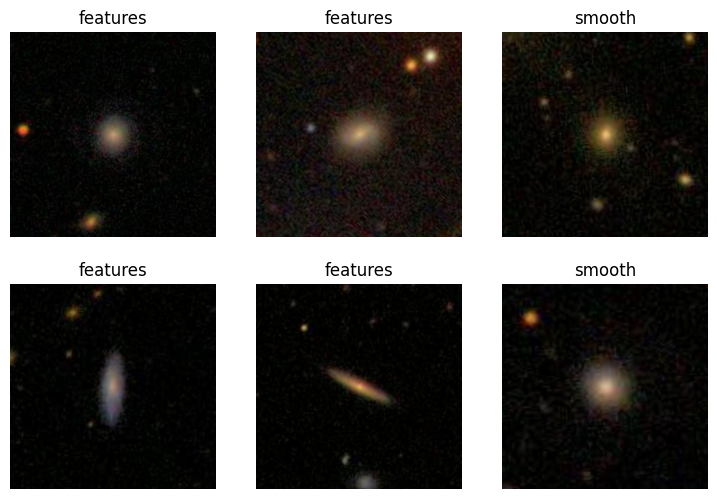

In [4]:
import zipfile, glob
import matplotlib.pyplot as plt
from PIL import Image

df = df[df["label"] != "star_or_artifact"].reset_index(drop=True)
print(df["label"].value_counts())

img_zip = glob.glob(base + "/images_training*.zip")[0]
with zipfile.ZipFile(img_zip) as z:
    z.extractall("/kaggle/working")

img_dir = glob.glob("/kaggle/working/images_training*")[0]
print(img_dir, len(os.listdir(img_dir)))

sample = df.sample(6, random_state=1)
fig, axes = plt.subplots(2, 3, figsize=(9, 6))
for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    ax.imshow(Image.open(f"{img_dir}/{int(row.GalaxyID)}.jpg"))
    ax.set_title(row.label)
    ax.axis("off")
plt.show()

In [5]:
import numpy as np
from sklearn.model_selection import train_test_split

small = pd.concat([
    df[df.label == "smooth"].sample(6000, random_state=1),
    df[df.label == "features"].sample(6000, random_state=1),
]).sample(frac=1, random_state=1).reset_index(drop=True)

def load(gid):
    im = Image.open(f"{img_dir}/{gid}.jpg").crop((106, 106, 318, 318)).resize((64, 64))
    return np.asarray(im, dtype="uint8")

X = np.stack([load(g) for g in small.GalaxyID])
y = (small.label == "features").astype("int").values
print(X.shape, y.shape, y.mean())

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)
print(X_train.shape, X_val.shape)

(12000, 64, 64, 3) (12000,) 0.5
(9600, 64, 64, 3) (2400, 64, 64, 3)


In [6]:
from tensorflow import keras
from tensorflow.keras import layers

Xtr = X_train.astype("float32") / 255.0
Xva = X_val.astype("float32") / 255.0

model = keras.Sequential([
    layers.Input(shape=(64, 64, 3)),
    layers.Conv2D(16, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history = model.fit(Xtr, y_train, validation_data=(Xva, y_val), epochs=8, batch_size=64)

2026-10-03 16:55:09.281688: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/8
150/150 ━━━━━━━━━━━━━━━━━━━━ 18s 107ms/step - accuracy: 0.7090 - loss: 0.5657 - val_accuracy: 0.7825 - val_loss: 0.4955
Epoch 2/8
150/150 ━━━━━━━━━━━━━━━━━━━━ 16s 104ms/step - accuracy: 0.7777 - loss: 0.4903 - val_accuracy: 0.7975 - val_loss: 0.4599
Epoch 3/8
150/150 ━━━━━━━━━━━━━━━━━━━━ 16s 104ms/step - accuracy: 0.7904 - loss: 0.4679 - val_accuracy: 0.8021 - val_loss: 0.4505
Epoch 4/8
150/150 ━━━━━━━━━━━━━━━━━━━━ 16s 103ms/step - accuracy: 0.7909 - loss: 0.4592 - val_accuracy: 0.7867 - val_loss: 0.4654
Epoch 5/8
150/150 ━━━━━━━━━━━━━━━━━━━━ 15s 103ms/step - accuracy: 0.8019 - loss: 0.4417 - val_accuracy: 0.8129 - val_loss: 0.4336
Epoch 6/8
150/150 ━━━━━━━━━━━━━━━━━━━━ 21s 104ms/step - accuracy: 0.8069 - loss: 0.4319 - val_accuracy: 0.8192 - val_loss: 0.4265
Epoch 7/8
150/150 ━━━━━━━━━━━━━━━━━━━━ 16s 103ms/step - accuracy: 0.8121 - loss: 0.4211 - val_accuracy: 0.8138 - val_loss: 0.4266
Epoch 8/8
150/150 ━━━━━━━━━━━━━━━━━━━━ 15s 102ms/step - accuracy: 0.8146 - loss: 0.4118 - 

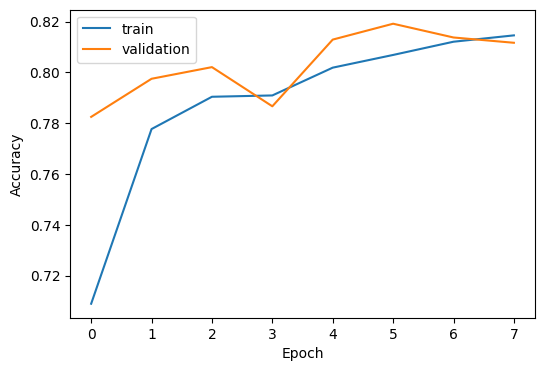

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
[[ 927  273]
 [ 179 1021]]
              precision    recall  f1-score   support

      smooth       0.84      0.77      0.80      1200
    features       0.79      0.85      0.82      1200

    accuracy                           0.81      2400
   macro avg       0.81      0.81      0.81      2400
weighted avg       0.81      0.81      0.81      2400



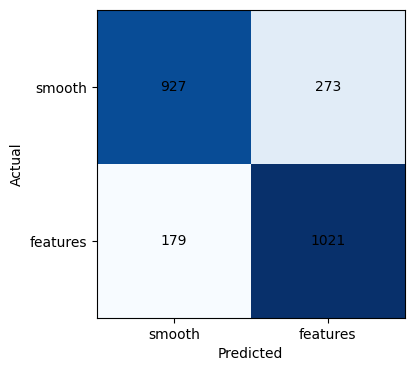

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

plt.figure(figsize=(6, 4))
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig("accuracy_curve.png", dpi=150)
plt.show()

pred = (model.predict(Xva) > 0.5).astype(int).ravel()
cm = confusion_matrix(y_val, pred)
print(cm)
print(classification_report(y_val, pred, target_names=["smooth", "features"]))

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_xticklabels(["smooth", "features"])
ax.set_yticks([0, 1])
ax.set_yticklabels(["smooth", "features"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center")
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()